In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('social_media_usage.csv')
df.head(5)

,User_ID,App,Daily_Minutes_Spent,Posts_Per_Day,Likes_Per_Day,Follows_Per_Day
0,U_1,Pinterest,288,16,94,0
1,U_2,Facebook,192,14,117,15
2,U_3,Instagram,351,13,120,48
3,U_4,TikTok,21,20,117,8
4,U_5,LinkedIn,241,16,9,21


In [4]:
df_insta = df[df['App'] == 'Instagram']
df_facebook = df[df['App'] == 'Facebook']

In [7]:
corr_overall = df[['Daily_Minutes_Spent','Posts_Per_Day']].corr()
corr_insta = df_insta[['Daily_Minutes_Spent','Posts_Per_Day']].corr()
corr_facebook = df_facebook[['Daily_Minutes_Spent','Posts_Per_Day']].corr()
print(corr_overall,'\n', corr_insta,'\n', corr_facebook)

                     Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent             1.000000      -0.023968
Posts_Per_Day                  -0.023968       1.000000 
                      Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent             1.000000      -0.075716
Posts_Per_Day                  -0.075716       1.000000 
                      Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent              1.00000       -0.05709
Posts_Per_Day                   -0.05709        1.00000


In [8]:
cov_overall = df[['Daily_Minutes_Spent','Posts_Per_Day']].cov()
cov_insta = df_insta[['Daily_Minutes_Spent','Posts_Per_Day']].cov()
cov_facebook = df_facebook[['Daily_Minutes_Spent','Posts_Per_Day']].cov()
print(cov_overall,'\n', cov_insta,'\n', cov_facebook)

                     Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent         21424.739315     -21.476468
Posts_Per_Day                 -21.476468      37.476115 
                      Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent         22820.392806     -67.486331
Posts_Per_Day                 -67.486331      34.812127 
                      Daily_Minutes_Spent  Posts_Per_Day
Daily_Minutes_Spent         23610.052669     -56.051906
Posts_Per_Day                 -56.051906      40.829139


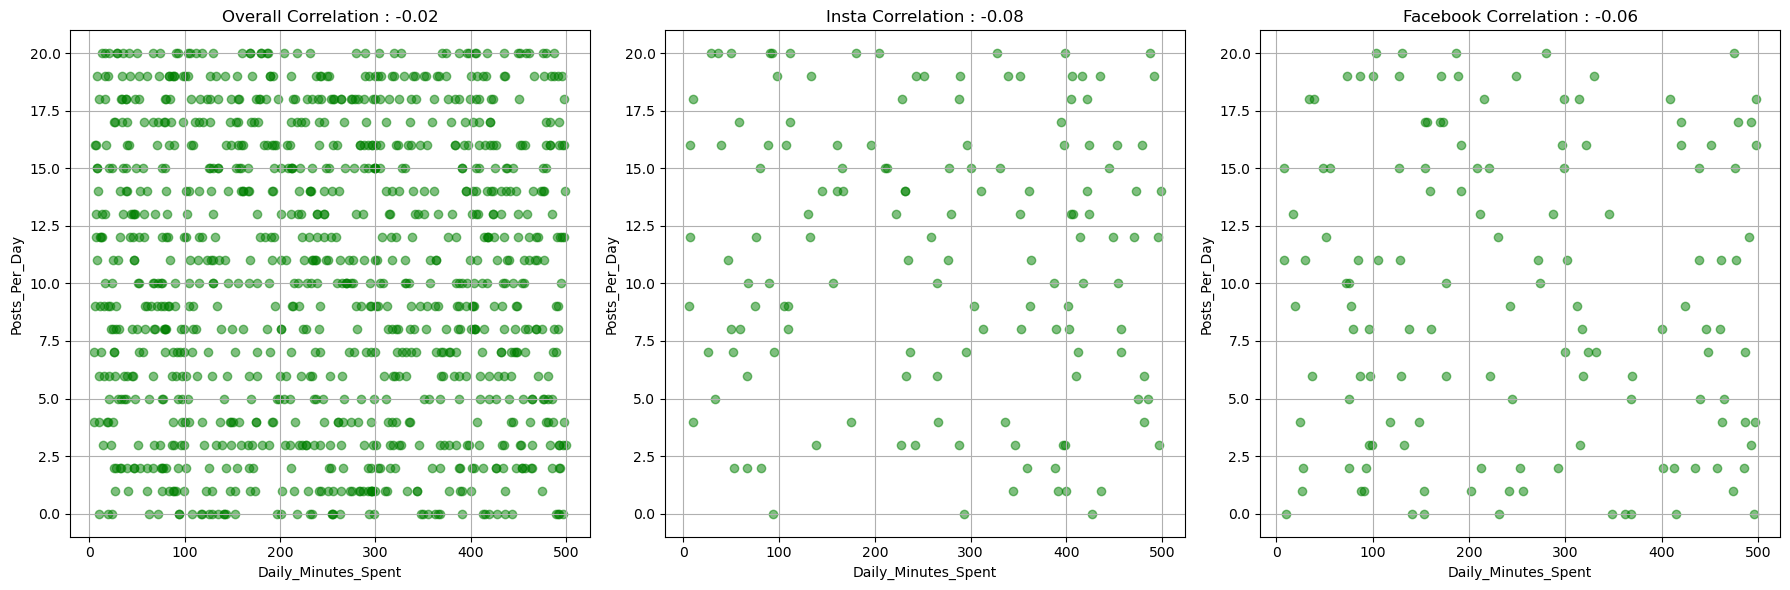

In [11]:
fig, axes = plt.subplots(1,3, figsize = (18,6))
axes[0].scatter(df['Daily_Minutes_Spent'], df['Posts_Per_Day'], color ='green', alpha = 0.5)
axes[0].set_title(f'Overall Correlation : {corr_overall.loc['Daily_Minutes_Spent','Posts_Per_Day']:.2f}')
axes[0].set_xlabel('Daily_Minutes_Spent')
axes[0].set_ylabel('Posts_Per_Day')
axes[0].grid(True)

#Male data plot
axes[1].scatter(df_insta['Daily_Minutes_Spent'], df_insta['Posts_Per_Day'], color ='green', alpha = 0.5)
axes[1].set_title(f'Insta Correlation : {corr_insta.loc['Daily_Minutes_Spent','Posts_Per_Day']:.2f}')
axes[1].set_xlabel('Daily_Minutes_Spent')
axes[1].set_ylabel('Posts_Per_Day')
axes[1].grid(True)

#Female data plot
axes[2].scatter(df_facebook['Daily_Minutes_Spent'], df_facebook['Posts_Per_Day'], color ='green', alpha = 0.5)
axes[2].set_title(f'Facebook Correlation : {corr_facebook.loc['Daily_Minutes_Spent','Posts_Per_Day']:.2f}')
axes[2].set_xlabel('Daily_Minutes_Spent')
axes[2].set_ylabel('Posts_Per_Day')
axes[2].grid(True)

plt.tight_layout()
plt.show()

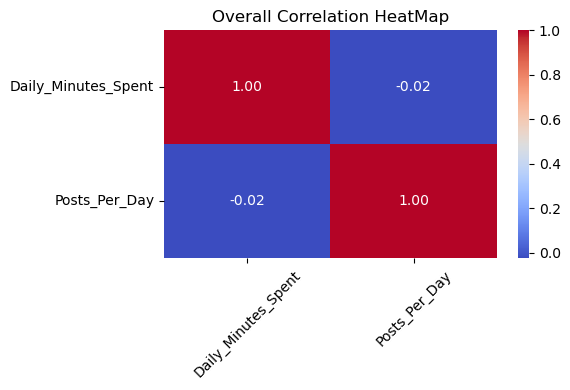

In [12]:
import seaborn as sns
plt.figure(figsize = (6,4))
sns.heatmap(corr_overall,annot=True,fmt=".2f",cmap ="coolwarm")
plt.title('Overall Correlation HeatMap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
df_2015 = pd.read_csv('marathon_results_2015.csv')
df_2016 = pd.read_csv('marathon_results_2016.csv')
df_2017 = pd.read_csv('marathon_results_2017.csv')

df6 = pd.concat([df_2015, df_2016, df_2017])
df6.head()

,Unnamed: 0,Bib,Name,Age,M/F,City,State,Country,Citizen,Unnamed: 9,...,30K,35K,40K,Pace,Proj Time,Official Time,Overall,Gender,Division,Unnamed: 8
0,0.0,3,"Desisa, Lelisa",25,M,Ambo,NaN,ETH,NaN,NaN,...,1:32:00,1:47:59,2:02:39,0:04:56,-,2:09:17,1,1,1,NaN
1,1.0,4,"Tsegay, Yemane Adhane",30,M,Addis Ababa,NaN,ETH,NaN,NaN,...,1:31:59,1:47:59,2:02:42,0:04:58,-,2:09:48,2,2,2,NaN
2,2.0,8,"Chebet, Wilson",29,M,Marakwet,NaN,KEN,NaN,NaN,...,1:32:00,1:47:59,2:03:01,0:04:59,-,2:10:22,3,3,3,NaN
3,3.0,11,"Kipyego, Bernard",28,M,Eldoret,NaN,KEN,NaN,NaN,...,1:32:00,1:48:03,2:03:47,0:05:00,-,2:10:47,4,4,4,NaN
4,4.0,10,"Korir, Wesley",32,M,Kitale,NaN,KEN,NaN,NaN,...,1:32:00,1:47:59,2:03:27,0:05:00,-,2:10:49,5,5,5,NaN


In [21]:
df6['Official Time'] = pd.to_timedelta(df6['Official Time'])
df6['Official Time'] = df6['Official Time'].dt.total_seconds()

df6['Pace'] = pd.to_timedelta(df6['Pace'])
df6['Pace'] = df6['Pace'].dt.total_seconds()
corr_overall = df6[['Official Time','Pace']].corr()
print(corr_overall)

               Official Time      Pace
Official Time       1.000000  0.999667
Pace                0.999667  1.000000


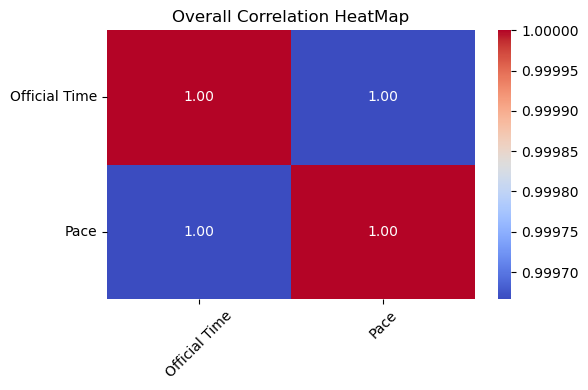

In [27]:
#HeatMAp
import seaborn as sns
plt.figure(figsize = (6,4))
sns.heatmap(corr_overall,annot=True,fmt=".2f",cmap ="coolwarm")
plt.title('Overall Correlation HeatMap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()